In [79]:
# clear all to reset
import os
os.system('clear')

1

In [80]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('hand_landmarks.csv')

# Show the first few rows of the DataFrame
df.head()


,timestamp,landmark_index,x,y,z
0,0.646249,0,0.664654,0.538736,7.867960e-07
1,0.646249,1,0.652573,0.514098,-8.582240e-02
2,0.646249,2,0.662268,0.483568,-1.320336e-01
3,0.646249,3,0.681923,0.473204,-1.643895e-01
4,0.646249,4,0.714070,0.462671,-1.966137e-01


In [81]:
# Group by timestamp to process each frame separately
grouped_frames = df.groupby('timestamp')

# Inspect the first frame (group of landmarks)
first_frame = grouped_frames.get_group(df['timestamp'].unique()[0])
first_frame.head()


,timestamp,landmark_index,x,y,z
0,0.646249,0,0.664654,0.538736,7.867960e-07
1,0.646249,1,0.652573,0.514098,-8.582240e-02
2,0.646249,2,0.662268,0.483568,-1.320336e-01
3,0.646249,3,0.681923,0.473204,-1.643895e-01
4,0.646249,4,0.714070,0.462671,-1.966137e-01


In [82]:
import numpy as np
import pandas as pd

# Function to calculate the angle between three points (landmarks)
def calculate_angle(a, b, c):
    # Ensure no None values are passed for the calculation
    if None in (a[0], a[1], a[2], b[0], b[1], b[2], c[0], c[1], c[2]):
        return None  # Return None or NaN if any coordinate is missing
    
    # Vector AB and BC
    v1 = np.array([a[0] - b[0], a[1] - b[1], a[2] - b[2]])  # Vector AB
    v2 = np.array([c[0] - b[0], c[1] - b[1], c[2] - b[2]])  # Vector BC

    # Dot product and magnitudes
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Avoid division by zero
    if magnitude_v1 == 0 or magnitude_v2 == 0:
        return None

    # Cosine of the angle between v1 and v2
    cos_angle = dot_product / (magnitude_v1 * magnitude_v2)

    # Return the angle in degrees
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # Ensure the value is in the range [-1, 1]
    return np.degrees(angle)


In [83]:
# Function to calculate the speed of landmarks (xyz) the hand
def calculate_speed(df):
    # Calculate the speed of each landmark (xyz) using the difference between consecutive frames
    speed = df[['x', 'y', 'z']].diff().abs()
    
    return speed


In [84]:
# Put the landmarks into marker_positions variable
marker_positions = df[['x', 'y', 'z']].values

In [85]:
# Calculate the speed of the hand
speed = calculate_speed(first_frame)
speed.head()

,x,y,z
0,NaN,NaN,NaN
1,0.012081,0.024638,0.085823
2,0.009694,0.030530,0.046211
3,0.019655,0.010364,0.032356
4,0.032147,0.010533,0.032224


In [86]:
print(frame.head())


                timestamp         x         y         z
landmark_index                                         
0               10.822952  0.308687  0.660371  0.000002
1               10.822952  0.414159  0.733425  0.014823
2               10.822952  0.463525  0.772150 -0.040449
3               10.822952  0.483391  0.835738 -0.106656
4               10.822952  0.505896  0.895058 -0.181526


In [87]:
# Function to calculate angles for a frame
def calculate_finger_angles(frame):
    angles = {}
    
    # Safely retrieve landmarks and calculate angles
    def safe_loc(landmark_index):
        try:
            return frame.loc[landmark_index, ['x', 'y', 'z']]
        except KeyError:
            # If the landmark is missing, return a default value
            return pd.Series([None, None, None], index=['x', 'y', 'z'])

    # Thumb (landmarks 1-4)
    thumb_angle = calculate_angle(safe_loc(1), safe_loc(2), safe_loc(3))
    angles['Thumb'] = thumb_angle
    
    # Index finger (landmarks 5-8)
    index_angle = calculate_angle(safe_loc(5), safe_loc(6), safe_loc(7))
    angles['Index'] = index_angle
    
    # Middle finger (landmarks 9-12)
    middle_angle = calculate_angle(safe_loc(9), safe_loc(10), safe_loc(11))
    angles['Middle'] = middle_angle
    
    # Ring finger (landmarks 13-16)
    ring_angle = calculate_angle(safe_loc(13), safe_loc(14), safe_loc(15))
    angles['Ring'] = ring_angle
    
    # Pinky finger (landmarks 17-20)
    pinky_angle = calculate_angle(safe_loc(17), safe_loc(18), safe_loc(19))
    angles['Pinky'] = pinky_angle
    
    return angles

# Ensure the DataFrame has the proper index by unpacking the tuple
# grouped_frames contains (timestamp, frame) tuples, we only want to apply set_index to the frame
grouped_frames = [(timestamp, frame.set_index('landmark_index')) for timestamp, frame in grouped_frames]

# Loop through frames and calculate angles for each frame
all_angles = {}
for timestamp, frame in grouped_frames:
    all_angles[timestamp] = calculate_finger_angles(frame)

C:\Users\FireP1-Labster\AppData\Local\Temp\ipykernel_27616\2240478329.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if None in (a[0], a[1], a[2], b[0], b[1], b[2], c[0], c[1], c[2]):
C:\Users\FireP1-Labster\AppData\Local\Temp\ipykernel_27616\2240478329.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  v1 = np.array([a[0] - b[0], a[1] - b[1], a[2] - b[2]])  # Vector AB
C:\Users\FireP1-Labster\AppData\Local\Temp\ipykernel_27616\2240478329.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFra

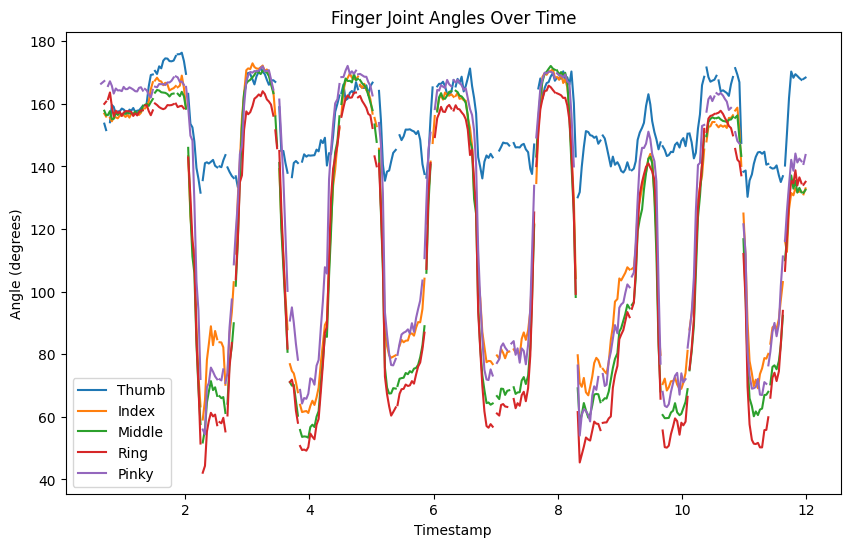

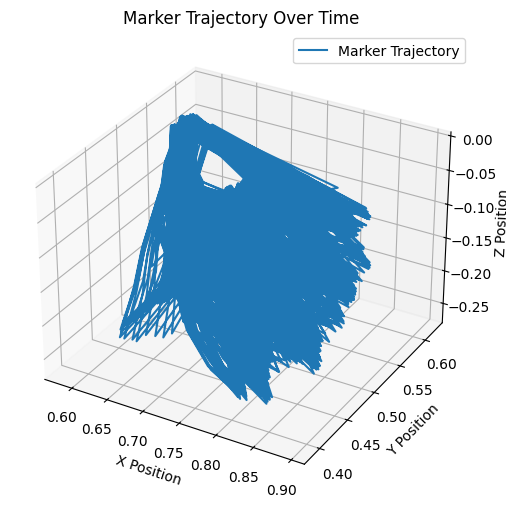

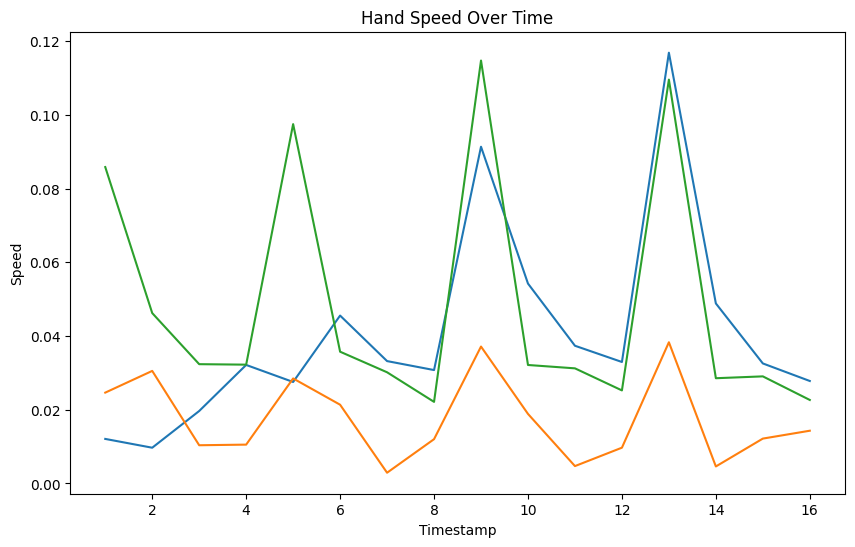

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming all_angles and marker_positions are already defined
# all_angles: Dictionary of angles with timestamps as keys
# marker_positions: Dictionary of marker positions with timestamps as keys

# Convert angles data into a DataFrame
angles_df = pd.DataFrame(all_angles).T  # Transpose to make timestamps the index

# Convert marker positions data into a DataFrame
marker_positions_df = pd.DataFrame(marker_positions)  # Transpose to make timestamps the index

# Convert speed data into a DataFrame
speed_df = pd.DataFrame(speed)  # Transpose to make timestamps the index

# Plot the angles over time
plt.figure(figsize=(10, 6))
for finger in angles_df.columns:
    plt.plot(angles_df.index, angles_df[finger], label=finger)

plt.title('Finger Joint Angles Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.show()

# Plot the trajectory of the marker
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(marker_positions_df[0], marker_positions_df[1], marker_positions_df[2], label='Marker Trajectory')

ax.set_title('Marker Trajectory Over Time')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
plt.show()

# Plot the speed of the hand over time
plt.figure(figsize=(10, 6))
plt.plot(speed_df.index, speed_df)
plt.title('Hand Speed Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Speed')
plt.show()

# Save the processed data to CSV files
angles_df.to_csv('finger_angles.csv')
marker_positions_df.to_csv('marker_positions.csv')
speed_df.to_csv('hand_speed.csv')